<a href="https://colab.research.google.com/github/Shavkatov-dev/computer_vision/blob/main/menu_detector_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
print("Menu Detector!")

Menu Detector!


In [2]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [3]:
import torchvision.transforms as transforms
from torchvision.models import mobilenet_v2
import torch.nn as nn
import torch
import torch.optim as optim

from PIL import Image
from torch.utils.data import Dataset, DataLoader
from PIL import UnidentifiedImageError
import os
import numpy as np



In [4]:
# Define dataset path
DATASET_PATH = '/content/drive/MyDrive/kaggle/images/'
print("Dataset Path: ", DATASET_PATH)

CUSTOM_CLASS_MAPPING = {
    'hamburger': 'hamburger',
    'hot_dog': 'hot_dog',
    "chocolate_cake" : "dessert",  # label grouping | class consolidation
    "cheesecake" : "dessert",  # label grouping | class consolidation
    "bibimbap": "bibimbap",
    "baklava" : "dessert", # label grouping | class consolidation
    'lasagna': 'salad',
    'pilaf_images': 'pilaf_images'
}


CLASSES = ['hamburger', 'hot_dog', 'dessert','salad', 'pilaf_images', "bibimbap"]
COLORS = ['white','black', 'red', 'blue']
CLASS_TO_IDX = {cls: i for i, cls in enumerate(CLASSES)}
COLORS_TO_IDX = {cls: i for i, cls in enumerate(COLORS)}
print(COLORS_TO_IDX)
NUM_CLASS = len(CLASSES)
print(CLASS_TO_IDX)
print("Number of Classes: ", NUM_CLASS)


transform = transforms.Compose([
    transforms.Resize((224,224)), #image resizing
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

#300x400, 512x512
# H, W, C => H, W, C
# Normalize
# pixel = (pixel - mean) / std

Dataset Path:  /content/drive/MyDrive/kaggle/images/
{'white': 0, 'black': 1, 'red': 2, 'blue': 3}
{'hamburger': 0, 'hot_dog': 1, 'dessert': 2, 'salad': 3, 'pilaf_images': 4, 'bibimbap': 5}
Number of Classes:  6


In [5]:
# ----------
# Custom Dataset class
# ----------

class FoodDataset(Dataset):
  def __init__(self, images, labels, transform=None):
    self.images = images
    self.transform = transform
    self.labels = labels

  def __len__(self):
    # print("images_length:", len(self.images))
    return len(self.images)

  def __getitem__ (self, idx):
    img_path = self.images[idx]
    # print('images_path', img_path)
    label = self.labels[idx]
    # print('label', label)
    try:
      image = Image.open(img_path)
      if image.mode == "P" or image.mode == "RGBA":
        image = image.convert("RGBA").convert("RGB")
      else:
          image = image.convert("RGB")
    except (UnidentifiedImageError, OSError):
      print(f'Skipping broken image: {img_path}')
      return self.__getitem__((idx + 1) % len(self.images))
    if self.transform:
      image = self.transform(image)
      return image, label


In [6]:
# -----------------------------
# Gather and Split Data
# -----------------------------
all_images = []
for original_class, mapped_class in CUSTOM_CLASS_MAPPING.items():
    class_path = os.path.join(DATASET_PATH, original_class) # /content/drive/MyDrive/kaggle/images/apple-pie
    print('class_path:', class_path)
    if not os.path.exists(class_path): # Corrected line: removed extra '.path'
        print(f"Warning: {class_path} not found")
        continue
    for img in os.listdir(class_path):
        if img.endswith(('.jpg', '.jpeg', '.png')):
            full_path = os.path.join(class_path, img) # /content/drive/MyDrive/kaggle/images/apple-pie/1001.jpg
            all_images.append((full_path, CLASS_TO_IDX[mapped_class]))

np.random.shuffle(all_images)
split = int(0.8 * len(all_images))
train_data = all_images[:split] #1000 => 800 | split | 200
val_data = all_images[split:]

train_images, train_labels = zip(*train_data)
val_images, val_labels = zip(*val_data)

# print('all_images:', all_images)

dataset = FoodDataset(train_images, train_labels, transform=transform) # Corrected: Added transform=transform
print(len(dataset))
img, lbl = dataset[0]

class_path: /content/drive/MyDrive/kaggle/images/hamburger
class_path: /content/drive/MyDrive/kaggle/images/hot_dog
class_path: /content/drive/MyDrive/kaggle/images/chocolate_cake
class_path: /content/drive/MyDrive/kaggle/images/cheesecake
class_path: /content/drive/MyDrive/kaggle/images/bibimbap
class_path: /content/drive/MyDrive/kaggle/images/baklava
class_path: /content/drive/MyDrive/kaggle/images/lasagna
class_path: /content/drive/MyDrive/kaggle/images/pilaf_images
5674


In [7]:
train_dataset = FoodDataset(train_images, train_labels, transform=transform)
val_dataset = FoodDataset(val_images, val_labels, transform=transform)

In [8]:
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=2) #thread | parallel loading for speed - num_workers
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False, num_workers=2)

In [9]:
# pretrained model
model = mobilenet_v2(weights='IMAGENET1K_V1') # lightweight | CNN | 1000 class | million
model.classifier[1] = nn.Linear(model.classifier[1].in_features, NUM_CLASS) # fine_tuning | backbne asl miyasini uzini ishlatish | model layer freeze

Downloading: "https://download.pytorch.org/models/mobilenet_v2-b0353104.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v2-b0353104.pth


100%|██████████| 13.6M/13.6M [00:00<00:00, 86.9MB/s]


In [10]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('device', device)
model = model.to(device)

device cuda


In [11]:
criteration = nn.CrossEntropyLoss() # Loss Function multiclass Classification '70%' burger, "30%" pilaf
optimizer = optim.Adam(model.parameters(), lr=0.001)  # weight
torch.backends.cudnn.benchmark = True #  Benchmark Setting | Trick | 10%-20%

In [12]:
# -----------------------------
# Training Loop
# -----------------------------

NUM_EPOCHS = 10                    # Total number of times the model will see the entire training dataset
best_accuracy = 0.0                # Store the highest validation accuracy achieved

for epoch in range(NUM_EPOCHS):    # Loop through each epoch

    # -----------------------------
    # Training Phase
    # -----------------------------
    model.train()                  # Set the model to training mode
                                   # (enables Dropout and updates BatchNorm statistics)

    running_loss = 0.0             # Reset the total loss for this epoch

    # Iterate through each batch of training data
    for images, labels in train_loader:

        # Move the current batch of images and labels to the selected device (CPU or GPU)
        images = images.to(device)
        labels = labels.to(device)

        # Clear gradients from the previous batch
        # PyTorch accumulates gradients by default
        optimizer.zero_grad()

        # Forward pass:
        # Pass the images through the neural network to obtain predictions
        outputs = model(images)

        # Compute the loss by comparing predictions with the true labels
        loss = criteration(outputs, labels)

        # Backward pass:
        # Compute gradients of the loss with respect to every trainable parameter
        loss.backward()

        # Update model weights using the optimizer (e.g., Adam, SGD)
        optimizer.step()

        # Add the current batch loss to the running loss
        running_loss += loss.item()

    # -----------------------------
    # Validation Phase
    # -----------------------------
    model.eval()                   # Switch the model to evaluation mode
                                   # (Dropout is disabled and BatchNorm uses stored statistics)

    correct = 0                    # Number of correctly predicted samples
    total = 0                      # Total number of validation samples

    # Disable gradient computation since we are only evaluating
    # This reduces memory usage and speeds up inference
    with torch.no_grad():

        # Iterate through each validation batch
        for images, labels in val_loader:

            # Move validation data to the selected device
            images = images.to(device)
            labels = labels.to(device)

            # Forward pass only
            outputs = model(images)

            # Get the predicted class index
            # torch.max returns:
            #   values      -> highest prediction score
            #   predicted   -> index of the highest score (predicted class)
            _, predicted = torch.max(outputs, dim=1)

            # Count the total number of validation samples
            total += labels.size(0)

            # Count how many predictions are correct
            correct += (predicted == labels).sum().item()

    # -----------------------------
    # Epoch Statistics
    # -----------------------------

    # Compute the average training loss for this epoch
    avg_loss = running_loss / len(train_loader)

    # Compute validation accuracy as a percentage
    val_acc = 100 * correct / total

    # Display the training progress
    print(
        f"Epoch [{epoch + 1}/{NUM_EPOCHS}] "
        f"Loss: {avg_loss:.4f} "
        f"Validation Accuracy: {val_acc:.2f}%"
    )

    # -----------------------------
    # Save the Best Model
    # -----------------------------
    # Save the model only if the validation accuracy improves
    if val_acc > best_accuracy:

        best_accuracy = val_acc

        # Save only the learned parameters (recommended practice)
        torch.save(model.state_dict(), "/content/menu_detector.pth")

        print("✅ New best model saved!")

Epoch [1/10] Loss: 0.5597 Validation Accuracy: 84.78%
✅ New best model saved!
Epoch [2/10] Loss: 0.3905 Validation Accuracy: 87.24%
✅ New best model saved!
Epoch [3/10] Loss: 0.3071 Validation Accuracy: 87.17%
Epoch [4/10] Loss: 0.2165 Validation Accuracy: 91.12%
✅ New best model saved!
Epoch [5/10] Loss: 0.2334 Validation Accuracy: 83.86%
Epoch [6/10] Loss: 0.1979 Validation Accuracy: 87.32%
Epoch [7/10] Loss: 0.1743 Validation Accuracy: 86.75%
Epoch [8/10] Loss: 0.2056 Validation Accuracy: 88.51%
Epoch [9/10] Loss: 0.1177 Validation Accuracy: 89.78%
Epoch [10/10] Loss: 0.1560 Validation Accuracy: 88.23%


# menu_detector modelusage

device: cuda
Upload one or more images of hamburger or hot dog:


Saving Bibimbap.jpg to Bibimbap.jpg


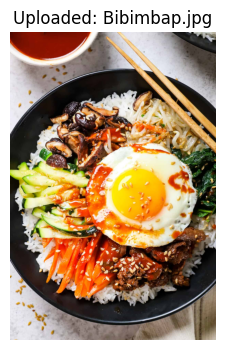

Prediction:
✅ bibimbap: 100.00%
✅ dessert: 0.00%
✅ salad: 0.00%
✅ hot_dog: 0.00%


In [13]:
# -----------------------------------------------
# Required Imports
# -----------------------------------------------
import torch
import torchvision.transforms as transforms
from torchvision.models import mobilenet_v2
from PIL import Image
from google.colab import files
import io
import matplotlib.pyplot as plt

# -----------------------------------------------
# Define Semantic Classes
# -----------------------------------------------
CLASSES = ['hamburger', 'hot_dog', 'dessert','salad', 'pilaf_images', "bibimbap"] # Must match training order
NUM_CLASSES = len(CLASSES)
CLASS_TO_IDX = {cls: i for i, cls in enumerate(CLASSES)}

# -----------------------------------------------
# Transform for Uploaded Images (no augmentations!)
# -----------------------------------------------
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

# -----------------------------------------------
# Load Model
# -----------------------------------------------
model = mobilenet_v2(weights=None)
model.classifier[1] = torch.nn.Linear(model.classifier[1].in_features, NUM_CLASSES)
model.load_state_dict(torch.load('/content/menu_detector.pth', map_location='cpu'))

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('device:', device)
model = model.to(device)
model.eval()

# -----------------------------------------------------------
# Upload & Predict
# -----------------------------------------------------------
print("Upload one or more images of hamburger or hot dog:")
uploaded = files.upload()

for image_name in uploaded.keys():
    image = Image.open(io.BytesIO(uploaded[image_name])).convert('RGB')

    # Display image
    plt.figure(figsize=(4, 4))
    plt.imshow(image)
    plt.axis('off')
    plt.title(f'Uploaded: {image_name}')
    plt.show()

    # Predict
    image_tensor = transform(image).unsqueeze(0).to(device)
    with torch.no_grad():
        output = model(image_tensor)
        probs = torch.softmax(output, dim=1)[0]
        topk = torch.topk(probs, 4)

    print("Prediction:")
    for i in range(topk.indices.size(0)):
        label = CLASSES[topk.indices[i]]
        confidence = topk.values[i].item() * 100
        print(f"✅ {label}: {confidence:.2f}%")